# SHAP Explainability — Street Segment Risk Classification

Explains **why** the logistic regression model assigns each street segment its risk class.

**Prerequisites:** Run `06_CityClassification.ipynb` first to produce a classified CSV for your target place.

**Model:** `LogisticRegression` (multi-class: `high`, `low`, `medium`)  
**Explainer:** `shap.LinearExplainer` — exact and fast for linear models  
**Output:** Dependence scatter · Waterfall · Summary · Force plots

## ⚙️ Configuration — Edit This Cell

In [4]:
# ── EDIT HERE ────────────────────────────────────────────────────────────────
PLACE = "Raval, Barcelona, Spain"   # Must match a classified CSV already in csv/
# e.g. "Eixample, Barcelona, Spain"
# e.g. "De Pijp, Amsterdam, Netherlands"

# Index of the segment to spotlight in waterfall / force plots
SAMPLE_IDX = 0
# ─────────────────────────────────────────────────────────────────────────────

import os
BASE_DIR   = r'C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding'
MODEL_DIR  = os.path.join(BASE_DIR, 'models')
OUTPUT_DIR = os.path.join(BASE_DIR, 'csv')

place_slug = PLACE.replace(',', '').replace(' ', '_').lower()
CSV_PATH   = os.path.join(OUTPUT_DIR, f'{place_slug}_classified.csv')

print(f'Target place : {PLACE}')
print(f'CSV path     : {CSV_PATH}')
print(f'Model dir    : {MODEL_DIR}')

Target place : Raval, Barcelona, Spain
CSV path     : C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\csv\raval_barcelona_spain_classified.csv
Model dir    : C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\models


## Step 1: Imports

In [5]:
import warnings
warnings.filterwarnings('ignore')

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

shap.initjs()   # enables JS-based force plots in notebook
print('✓ Imports OK')

✓ Imports OK


## Step 2: Load Model, Scaler & Classified Data

In [6]:
# Load trained artefacts
scaler = joblib.load(os.path.join(MODEL_DIR, 'scaler.pkl'))
model  = joblib.load(os.path.join(MODEL_DIR, 'logistic_regression.pkl'))

print('✓ Scaler loaded')
print('✓ Model loaded :', type(model).__name__)
print('  Classes      :', list(model.classes_))

# Load the classified CSV produced by 06_CityClassification
if not Path(CSV_PATH).exists():
    raise FileNotFoundError(
        f'No classified CSV found for "{PLACE}".\n'
        f'Run 06_CityClassification.ipynb with PLACE = "{PLACE}" first.\n'
        f'Expected: {CSV_PATH}'
    )

df = pd.read_csv(CSV_PATH)
print(f'\n✓ Loaded {len(df):,} segments from {CSV_PATH}')
print(df.head(3))

✓ Scaler loaded
✓ Model loaded : LogisticRegression
  Classes      : ['high', 'low', 'medium']

✓ Loaded 227 segments from C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\csv\raval_barcelona_spain_classified.csv
                  osmid  lighting  visibility  connectivity  enclosure  \
0  [8380803, 309051278]         0      0.8181             5   0.000356   
1             246638753         0      1.0000             4   0.000000   
2              18508391         0      1.0000             6   0.000000   

   dominant_land_use_score  public_transport_proximity_m  dist_to_rail_m  \
0                      0.5                         17.49           17.49   
1                      NaN                        121.77          121.77   
2                      NaN                         76.46           76.46   

   dist_to_bus_m  lighting_norm  visibility_norm  connectivity_norm  \
0          28.76            0.0         0.800044           0.222222   
1         125.82            0.0    

## Step 3: Prepare Feature Matrix

In [7]:
FEATURE_COLS = [
    'lighting_norm',
    'visibility_norm',
    'connectivity_norm',
    'enclosure_norm',
    'dominant_land_use_score_norm',
    'public_transport_proximity_m_norm',
]

# Human-readable labels for plots
FEATURE_LABELS = [
    'Lighting',
    'Visibility',
    'Connectivity',
    'Enclosure',
    'Land Use',
    'Transit Proximity',
]

X      = df[FEATURE_COLS].fillna(0).values
X_scaled = scaler.transform(X)

# DataFrame version for plot labels
X_df        = pd.DataFrame(X_scaled, columns=FEATURE_LABELS)
classes     = list(model.classes_)          # ['high', 'low', 'medium']

print(f'✓ Feature matrix: {X_df.shape}')
print(X_df.describe().round(3))

✓ Feature matrix: (227, 6)
       Lighting  Visibility  Connectivity  Enclosure  Land Use  \
count   227.000     227.000       227.000    227.000   227.000   
mean     -0.107      -0.629        -0.562      0.751    -0.247   
std       2.199       1.969         1.275      2.115     1.083   
min      -0.346      -3.970        -3.191     -1.919    -1.608   
25%      -0.346      -2.318        -1.186     -1.435    -1.030   
50%      -0.346      -1.019        -1.186      1.080    -0.437   
75%      -0.346       0.878         0.151      2.310     0.521   
max      26.810       2.575         2.824      5.683     3.581   

       Transit Proximity  
count            227.000  
mean               1.221  
std                1.514  
min               -1.465  
25%               -0.005  
50%                1.196  
75%                2.215  
max                5.712  


## Step 4: Build SHAP Explainer

`shap.LinearExplainer` is exact for logistic/linear models — no sampling needed, no speed trade-off.  
It returns one SHAP matrix per class (`shap_values` has shape `(n_samples, n_features, n_classes)`).

In [12]:
# SHAP's linear explainer can fail on multiclass logistic regression in correlation-dependent mode.
# Use the model's probability function with a tabular masker so all three classes are explained safely.
explainer   = shap.Explainer(model.predict_proba, shap.maskers.Independent(X_df), output_names=classes)
shap_values = explainer(X_df)   # Explanation object: .values shape = (n, features, classes)
base_values = np.asarray(shap_values.base_values)

print('✓ SHAP values computed')
print('  shap_values.values shape:', shap_values.values.shape)
print('  Classes order            :', classes)

Background dataset has 227 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=227 when initializing the masker.


✓ SHAP values computed
  shap_values.values shape: (227, 6, 3)
  Classes order            : ['high', 'low', 'medium']


## Step 5: Dependence Scatter Plots

**How to read:** X-axis = normalised feature value; Y-axis = SHAP contribution to that class.  
A downward slope means higher feature value → lower probability of that class, and vice versa.

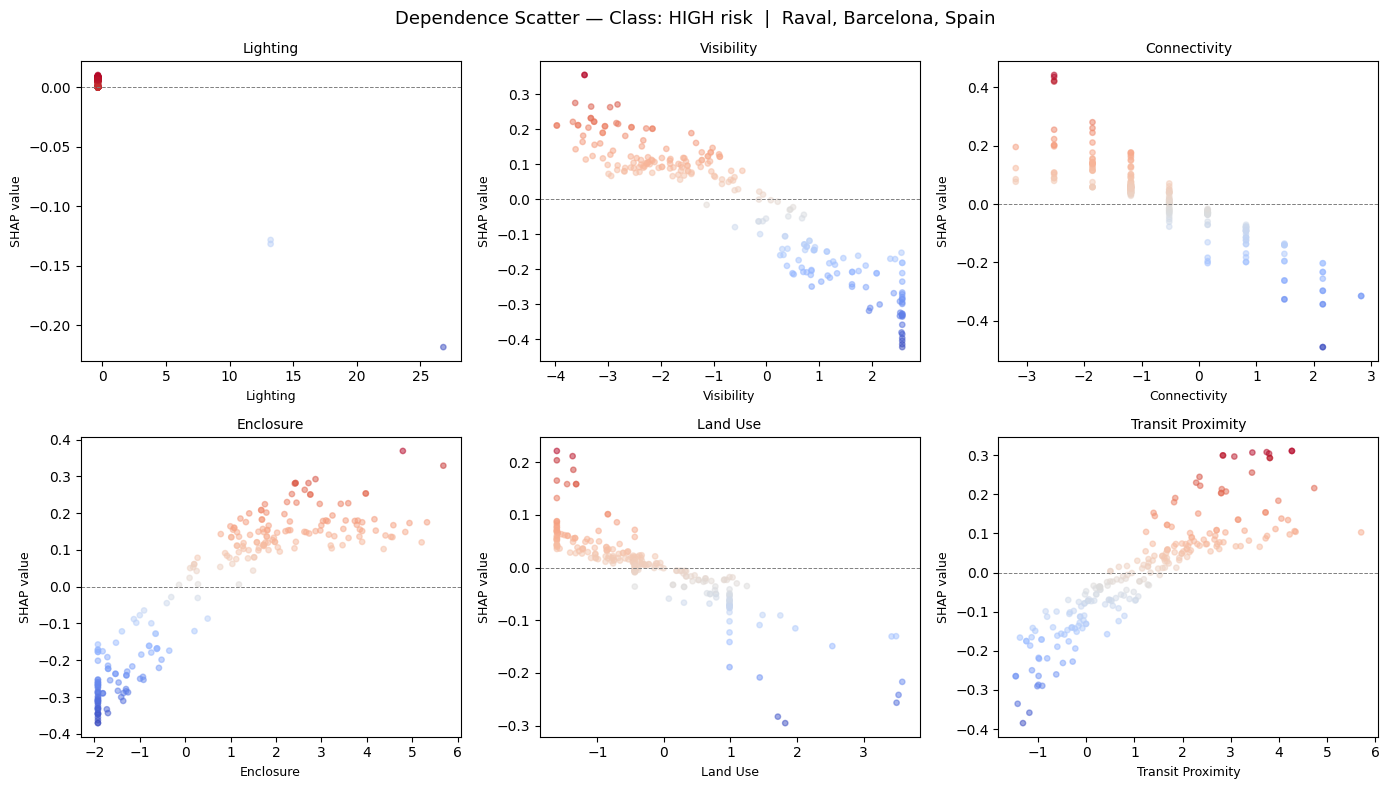

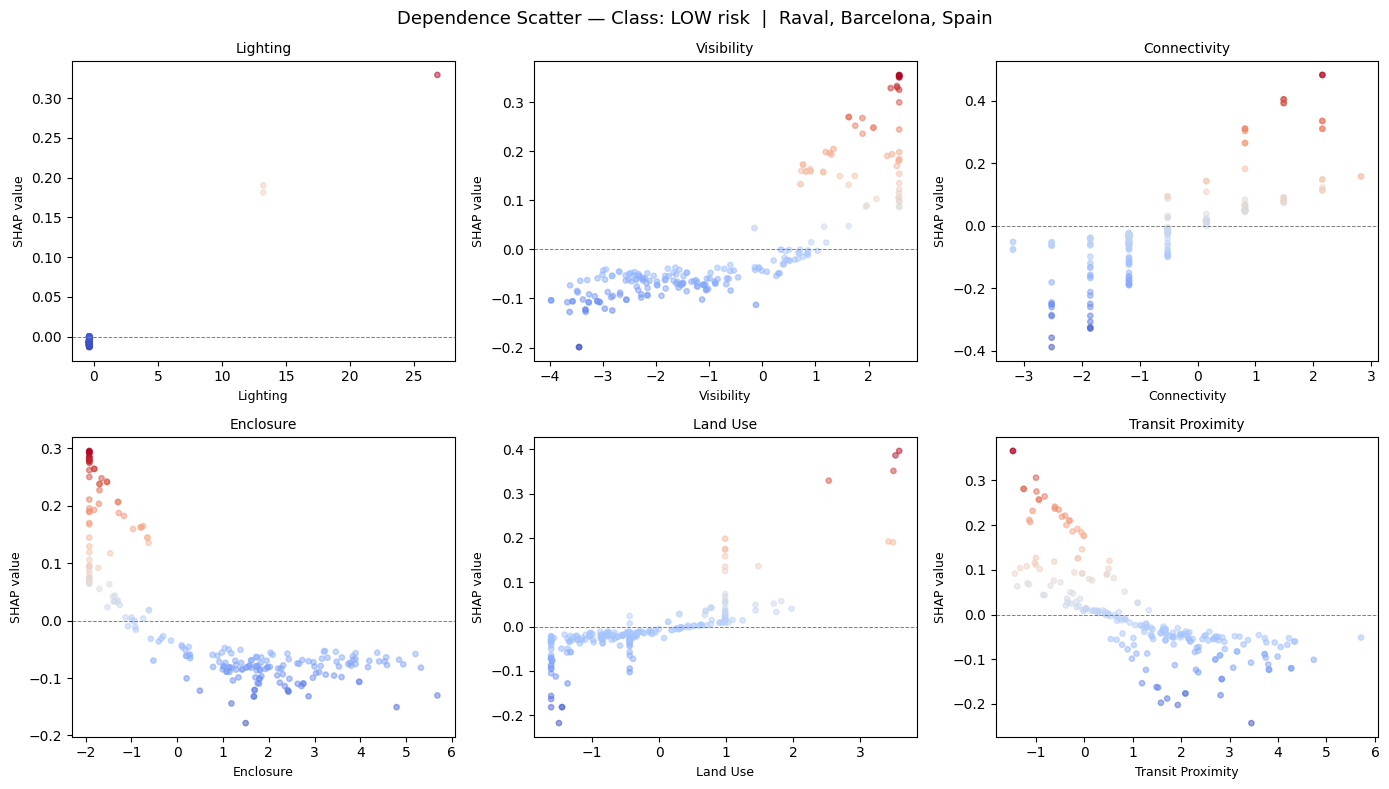

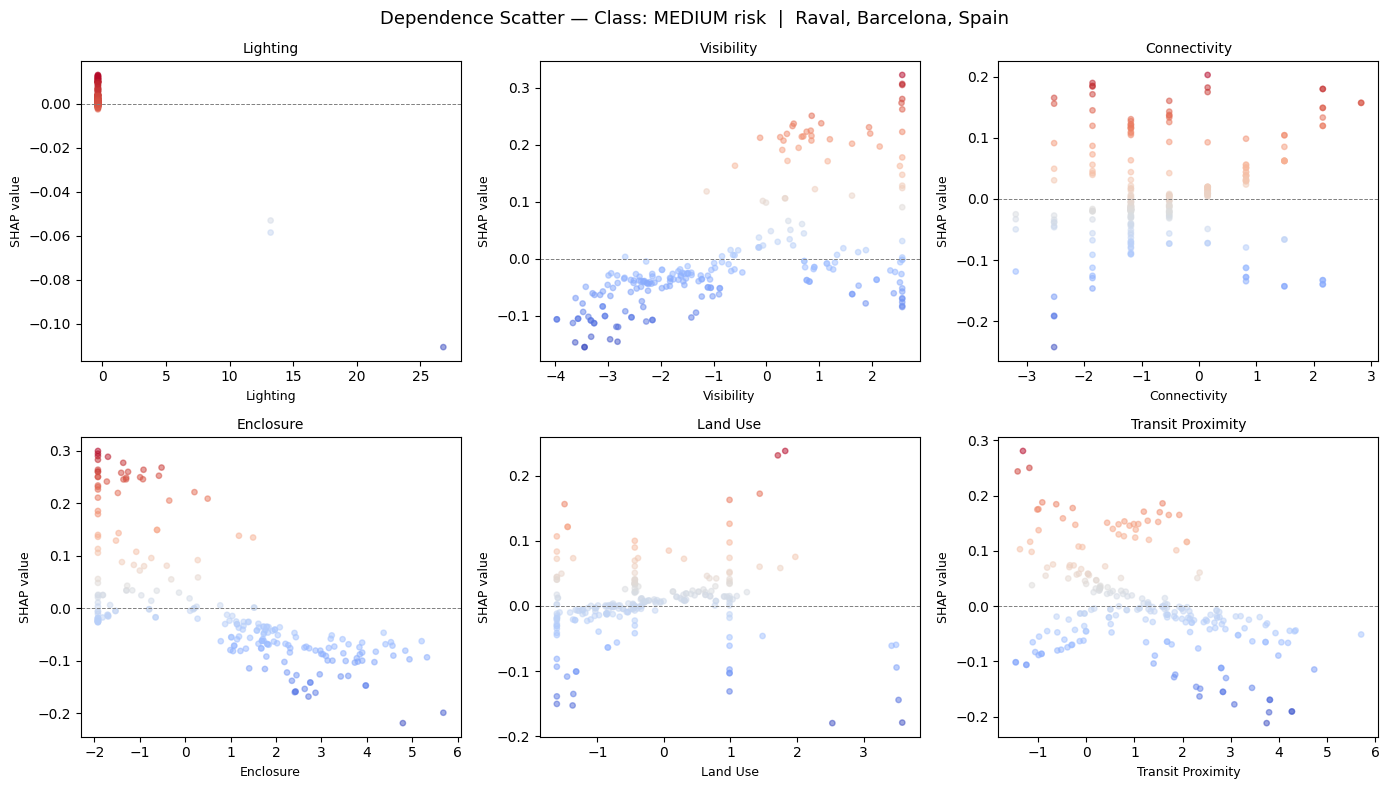

In [13]:
# Plot dependence scatter for each feature × each class
for class_idx, class_name in enumerate(classes):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle(f'Dependence Scatter — Class: {class_name.upper()} risk  |  {PLACE}', fontsize=13)

    for feat_idx, (feat_col, feat_label) in enumerate(zip(FEATURE_COLS, FEATURE_LABELS)):
        ax = axes[feat_idx // 3][feat_idx % 3]
        ax.scatter(
            X_df[feat_label],
            shap_values.values[:, feat_idx, class_idx],
            alpha=0.5, s=15, c=shap_values.values[:, feat_idx, class_idx],
            cmap='coolwarm'
        )
        ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
        ax.set_xlabel(feat_label, fontsize=9)
        ax.set_ylabel('SHAP value', fontsize=9)
        ax.set_title(feat_label, fontsize=10)

    plt.tight_layout()
    plt.show()

## Step 6: Summary Plot (Bar — Global Feature Importance)

Mean absolute SHAP value per feature across all segments and classes.  
Shows which features drive the model most overall.

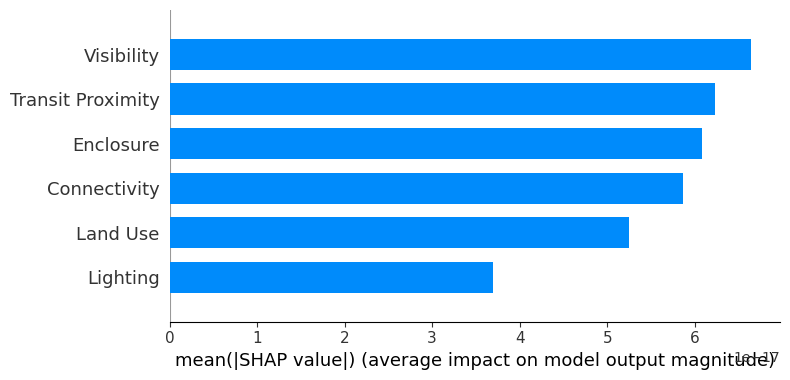

Text(0.5, 1.0, 'Global Feature Importance — Raval, Barcelona, Spain')

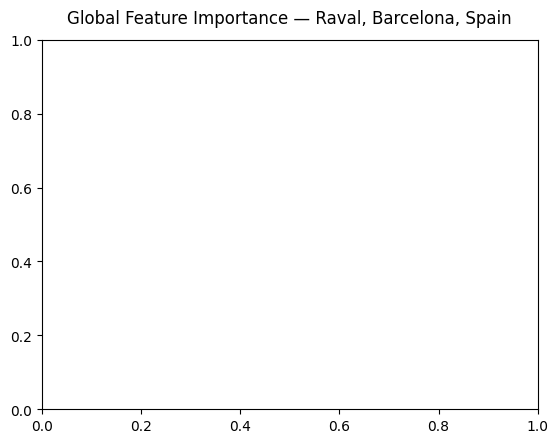

In [14]:
# shap.summary_plot expects (n_samples, n_features) — average across classes
shap_mean = shap_values.values.mean(axis=2)  # (n_samples, n_features)

shap.summary_plot(
    shap_mean,
    X_df,
    plot_type='bar',
    show=True
)
plt.title(f'Global Feature Importance — {PLACE}', pad=12)

## Step 7: Summary Plot (Dot — Per-Class Feature Effects)

One dot per segment. Colour = feature value (blue=low, red=high).  
X-axis spread shows direction and magnitude of effect on each class.


--- Class: HIGH risk ---


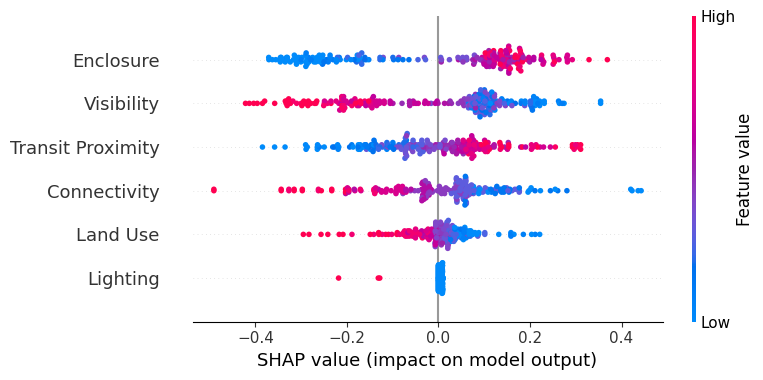


--- Class: LOW risk ---


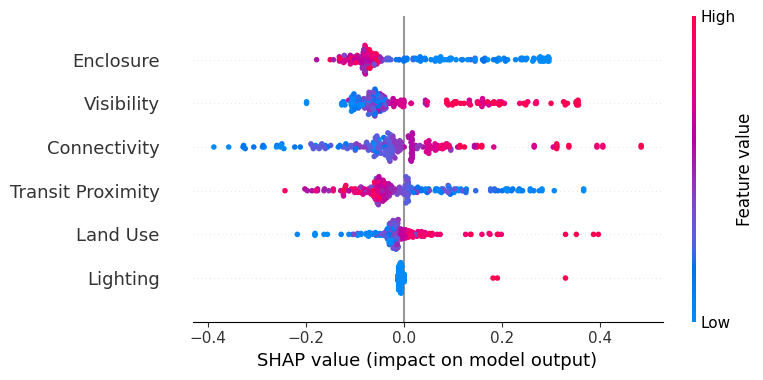


--- Class: MEDIUM risk ---


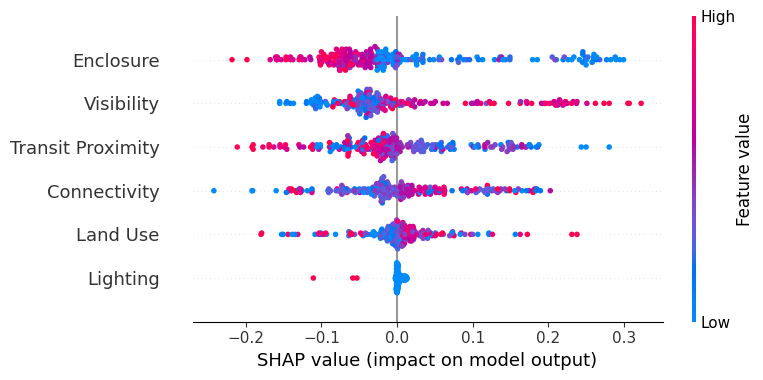

In [15]:
for class_idx, class_name in enumerate(classes):
    print(f'\n--- Class: {class_name.upper()} risk ---')
    shap.summary_plot(
        shap_values.values[:, :, class_idx],
        X_df,
        plot_type='dot',
        show=True
    )

## Step 8: Waterfall Plot — Single Segment

**How to read:** Starting from the base value (average model output), each bar shows how much one feature *pushes* the prediction up (red) or down (blue) for the predicted class of this segment.  

Change `SAMPLE_IDX` at the top to inspect any segment.

Segment 0 — predicted class: LOW risk
(showing SHAP values for class index 1: "low")


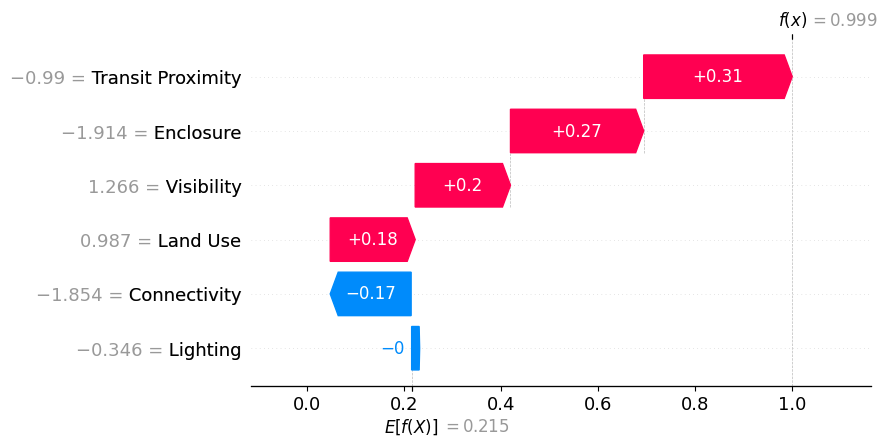

In [16]:
predicted_class     = df['risk_class'].iloc[SAMPLE_IDX]
predicted_class_idx = classes.index(predicted_class)

print(f'Segment {SAMPLE_IDX} — predicted class: {predicted_class.upper()} risk')
print(f'(showing SHAP values for class index {predicted_class_idx}: "{predicted_class}")')

exp_single = shap.Explanation(
    values       = shap_values.values[SAMPLE_IDX, :, predicted_class_idx],
    base_values  = base_values[SAMPLE_IDX, predicted_class_idx],
    data         = X_df.iloc[SAMPLE_IDX].values,
    feature_names= FEATURE_LABELS,
)

shap.plots.waterfall(exp_single)

## Step 9: Force Plot — Single Segment

Same information as the waterfall, but in a compact horizontal layout.  
Red features push the prediction higher; blue push it lower.

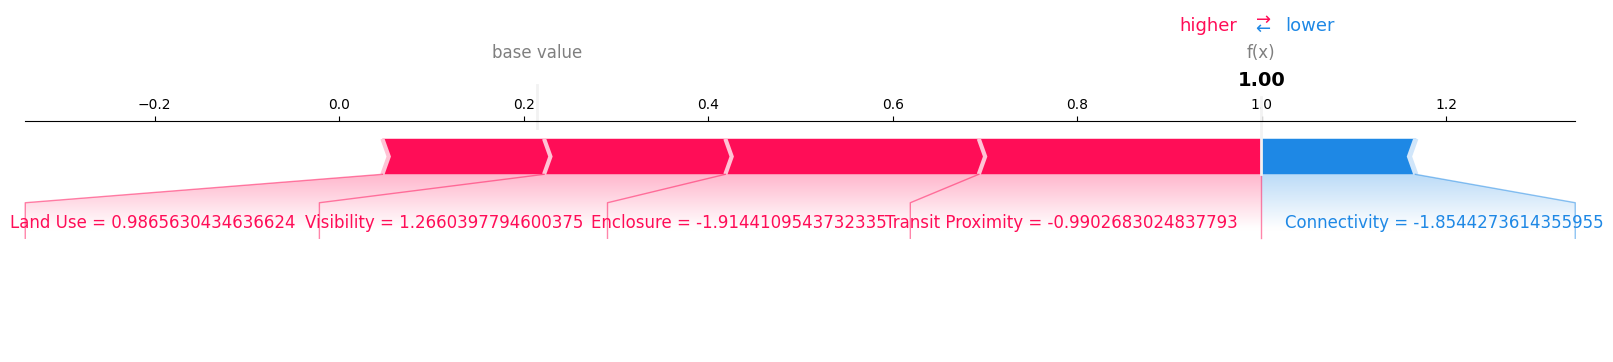

In [11]:
shap.force_plot(
    base_value    = base_values[SAMPLE_IDX, predicted_class_idx],
    shap_values   = shap_values.values[SAMPLE_IDX, :, predicted_class_idx],
    features      = X_df.iloc[SAMPLE_IDX],
    feature_names = FEATURE_LABELS,
    matplotlib    = True
)

## Step 10: Compare SHAP Profiles Across Risk Classes

Mean SHAP value per feature for each risk class.  
Reveals which features most distinguish, say, *high* from *low* risk segments.

Mean SHAP values per class:
        Lighting  Visibility  Connectivity  Enclosure  Land Use  \
class                                                             
high      0.0025     -0.0115        0.0076    -0.0101    0.0019   
low      -0.0040      0.0074       -0.0161     0.0059   -0.0066   
medium    0.0015      0.0041        0.0085     0.0042    0.0047   

        Transit Proximity  
class                      
high              -0.0023  
low                0.0005  
medium             0.0018  


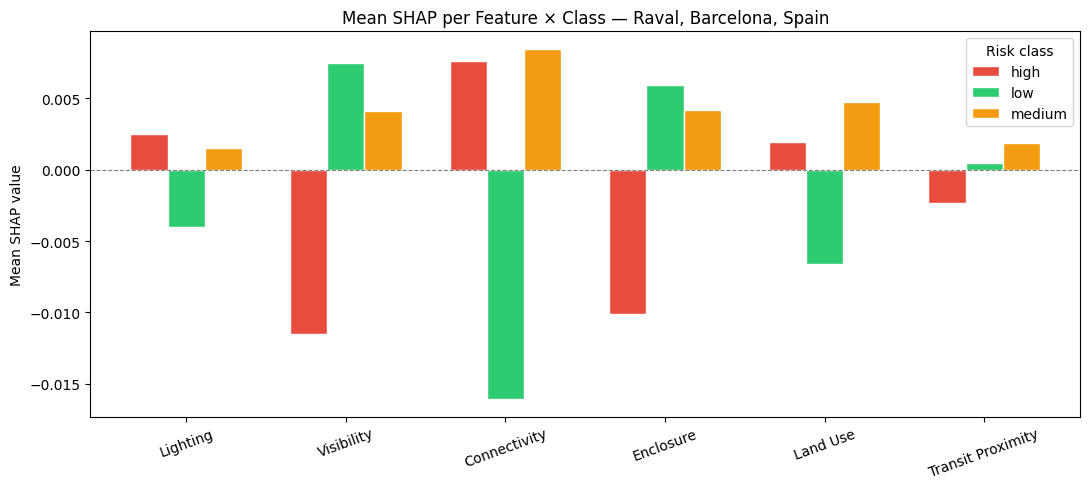

In [17]:
# Build a DataFrame: mean SHAP per class per feature
rows = []
for class_idx, class_name in enumerate(classes):
    mean_shap = shap_values.values[:, :, class_idx].mean(axis=0)
    rows.append(dict(zip(FEATURE_LABELS, mean_shap)) | {'class': class_name})

shap_profile = pd.DataFrame(rows).set_index('class')
print('Mean SHAP values per class:')
print(shap_profile.round(4))

# Grouped bar chart
ax = shap_profile.T.plot(
    kind='bar',
    figsize=(11, 5),
    color=['#e74c3c', '#2ecc71', '#f39c12'],
    edgecolor='white',
    width=0.7
)
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title(f'Mean SHAP per Feature × Class — {PLACE}', fontsize=12)
ax.set_ylabel('Mean SHAP value')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Risk class')
plt.tight_layout()
plt.show()

## Step 11: Export SHAP Values to CSV

One row per segment; one column per (feature × class) combination.  
Useful for mapping SHAP values spatially in QGIS or further analysis.

In [18]:
shap_rows = []
for class_idx, class_name in enumerate(classes):
    tmp = pd.DataFrame(
        shap_values.values[:, :, class_idx],
        columns=[f'shap_{feat}_{class_name}' for feat in FEATURE_LABELS]
    )
    shap_rows.append(tmp)

shap_df = pd.concat(shap_rows, axis=1)

# Attach osmid and predicted class if present
for col in ['osmid', 'risk_class', 'risk_probability']:
    if col in df.columns:
        shap_df.insert(0, col, df[col].values)

out_path = os.path.join(OUTPUT_DIR, f'{place_slug}_shap_values.csv')
shap_df.to_csv(out_path, index=False)
print(f'✓ SHAP values exported to: {out_path}')
print(f'  Columns: {list(shap_df.columns[:8])} ...')
shap_df.head(3)

✓ SHAP values exported to: C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\csv\raval_barcelona_spain_shap_values.csv
  Columns: ['risk_probability', 'risk_class', 'osmid', 'shap_Lighting_high', 'shap_Visibility_high', 'shap_Connectivity_high', 'shap_Enclosure_high', 'shap_Land Use_high'] ...


,risk_probability,risk_class,osmid,shap_Lighting_high,shap_Visibility_high,shap_Connectivity_high,shap_Enclosure_high,shap_Land Use_high,shap_Transit Proximity_high,shap_Lighting_low,...,shap_Connectivity_low,shap_Enclosure_low,shap_Land Use_low,shap_Transit Proximity_low,shap_Lighting_medium,shap_Visibility_medium,shap_Connectivity_medium,shap_Enclosure_medium,shap_Land Use_medium,shap_Transit Proximity_medium
0,0.9995,low,"[8380803, 309051278]",1.532663e-13,-0.177626,0.127537,-0.300698,-0.072130,-0.217853,-0.001049,...,-0.166827,0.274641,0.175213,0.306251,0.001049,-0.018817,0.039289,0.026056,-0.103083,-0.088398
1,0.8934,high,246638753,6.806402e-03,-0.234964,0.420166,-0.201340,0.071542,0.190461,-0.010750,...,-0.260212,0.065105,-0.029646,-0.066770,0.003944,0.147483,-0.159955,0.136235,-0.041897,-0.123690
2,0.7940,low,18508391,2.692291e-15,-0.330679,0.065751,-0.310789,0.000103,-0.065157,-0.002936,...,-0.068330,0.262225,0.006982,0.081624,0.002936,0.031057,0.002579,0.048563,-0.007085,-0.016467
